In this tutorial extension, we will use uproot data analysis and visualization. 

In [1]:
import ROOT
import uproot
import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.26/10


We start by plotting the time series of our simulated CCA CRES electron using ROOT as is done in the standard Katydid tutorial. This can be run after running the `00_barebones.yaml` file, which outputs `barebones.root` after processing. 

In [2]:
c0=ROOT.TCanvas("c0")
fFile = ROOT.TFile("barebones.root")
fFile.ls()

TFile**		barebones.root	
 TFile*		barebones.root	
  KEY: TH1D	histPS_0_0;2	Power Spectrum [current cycle]
  KEY: TH1D	histPS_0_0;1	Power Spectrum [backup cycle]
  KEY: TH1D	histTS_0_0;2	Time Series [current cycle]
  KEY: TH1D	histTS_0_0;1	Time Series [backup cycle]
  KEY: TH1D	histPS_1_0;2	Power Spectrum [current cycle]
  KEY: TH1D	histPS_1_0;1	Power Spectrum [backup cycle]
  KEY: TH1D	histTS_1_0;2	Time Series [current cycle]
  KEY: TH1D	histTS_1_0;1	Time Series [backup cycle]
  KEY: TH1D	histPS_2_0;2	Power Spectrum [current cycle]
  KEY: TH1D	histPS_2_0;1	Power Spectrum [backup cycle]
  KEY: TH1D	histTS_2_0;2	Time Series [current cycle]
  KEY: TH1D	histTS_2_0;1	Time Series [backup cycle]
  KEY: TH1D	histPS_3_0;2	Power Spectrum [current cycle]
  KEY: TH1D	histPS_3_0;1	Power Spectrum [backup cycle]
  KEY: TH1D	histTS_3_0;2	Time Series [current cycle]
  KEY: TH1D	histTS_3_0;1	Time Series [backup cycle]
  KEY: TH1D	histPS_4_0;2	Power Spectrum [current cycle]
  KEY: TH1D	histPS_4_0;1	Power

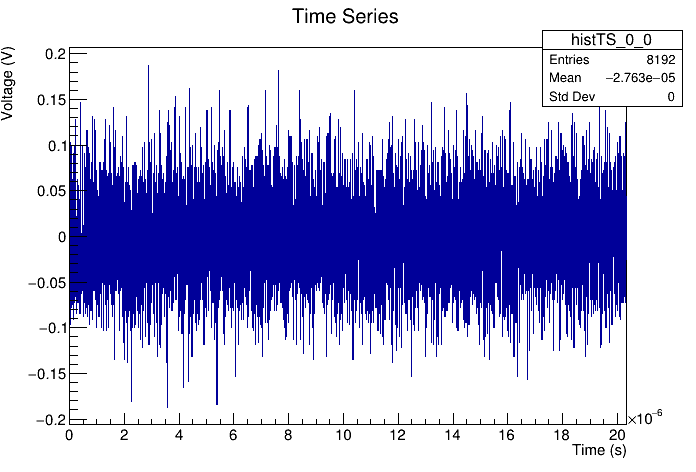

In [3]:
hTS = fFile.Get("histTS_0_0")
hTS.Draw()
c0.Draw()

ROOT file contents can be seen with uproot using either `.keys()` or `.classnames()` functions. The `.classnames()` function is effectively the same as using `.ls()` with ROOT.

In [4]:
rootfile_name = 'barebones.root'

rootFile = uproot.open(rootfile_name)
# Printing keys with associated objects
rootFile.classnames()

{'histPS_0_0;2': 'TH1D',
 'histPS_0_0;1': 'TH1D',
 'histTS_0_0;2': 'TH1D',
 'histTS_0_0;1': 'TH1D',
 'histPS_1_0;2': 'TH1D',
 'histPS_1_0;1': 'TH1D',
 'histTS_1_0;2': 'TH1D',
 'histTS_1_0;1': 'TH1D',
 'histPS_2_0;2': 'TH1D',
 'histPS_2_0;1': 'TH1D',
 'histTS_2_0;2': 'TH1D',
 'histTS_2_0;1': 'TH1D',
 'histPS_3_0;2': 'TH1D',
 'histPS_3_0;1': 'TH1D',
 'histTS_3_0;2': 'TH1D',
 'histTS_3_0;1': 'TH1D',
 'histPS_4_0;2': 'TH1D',
 'histPS_4_0;1': 'TH1D',
 'histTS_4_0;2': 'TH1D',
 'histTS_4_0;1': 'TH1D',
 'histPS_5_0;2': 'TH1D',
 'histPS_5_0;1': 'TH1D',
 'histTS_5_0;2': 'TH1D',
 'histTS_5_0;1': 'TH1D',
 'histPS_6_0;2': 'TH1D',
 'histPS_6_0;1': 'TH1D',
 'histTS_6_0;2': 'TH1D',
 'histTS_6_0;1': 'TH1D',
 'histPS_7_0;2': 'TH1D',
 'histPS_7_0;1': 'TH1D',
 'histTS_7_0;2': 'TH1D',
 'histTS_7_0;1': 'TH1D',
 'histPS_8_0;2': 'TH1D',
 'histPS_8_0;1': 'TH1D',
 'histTS_8_0;2': 'TH1D',
 'histTS_8_0;1': 'TH1D',
 'histPS_9_0;2': 'TH1D',
 'histPS_9_0;1': 'TH1D',
 'histTS_9_0;2': 'TH1D',
 'histTS_9_0;1': 'TH1D',


The data can be extracted to numpy arrays using `.to_numpy()`. Here we plot the time series produced by the processor connections:

```yaml
- signal: "egg:ts"
  slot: "writer:ts"
```


Text(0.5, 0, 'Time [s]')

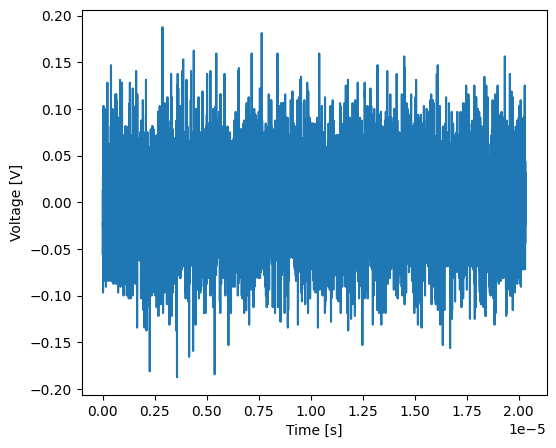

In [5]:
tsData = rootFile['histTS_0_0;2'].to_numpy()
tsVals = tsData[0]
tsEdges = tsData[1]

tsCenters = (tsEdges[:-1] + tsEdges[1:]) / 2

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(tsCenters, tsVals)
ax.set_ylabel('Voltage [V]')
ax.set_xlabel('Time [s]')

Now, we plot the power spectrum as in the Katydid tutorial.

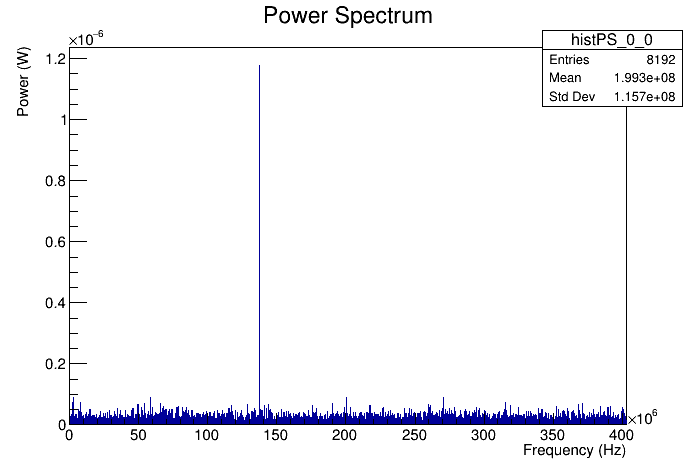

In [6]:
c1=ROOT.TCanvas("c1")
hPS = fFile.Get("histPS_0_0")
hPS.Draw()
c1.Draw()

Histogram data can also be extracted with uproot using `.values()` and `.axis().edges()`

Text(0.5, 0, 'Frequency [Hz]')

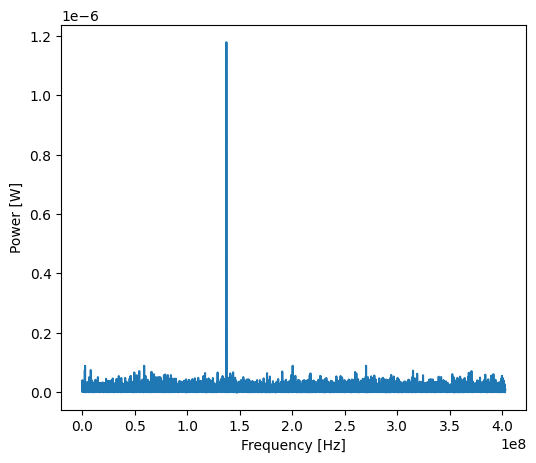

In [9]:
psData = rootFile['histPS_0_0;2']
psVals = psData.values()
psEdges = psData.axis().edges()

psCenters = (psEdges[:-1] + psEdges[1:]) / 2

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(psCenters, psVals)
ax.set_ylabel('Power [W]')
ax.set_xlabel('Frequency [Hz]')